# Regularization Methods

In this mini-project, two regularization methods, "Dropout" method and "L1L2" method is tested on a simple model for classification of a twp-labeled and two-dimensional dataset.

## Importing the packages

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt

import keras
from keras import regularizers

from regularization_utils import (
    plot_loss_acc,
    plot_decision_boundaries,
    plot_loss_acc_on_axes,
    plot_decision_boundaries_on_axes
)

In [3]:
os.environ["KERAS_BACKEND"] = "tensorflow"

## Loading datasets

In [4]:
data_train_x = np.load("data/data_X.npy")
data_train_y = np.load("data/data_y.npy")
data_eval_x = np.load("data/data_eval_X.npy")
data_eval_y = np.load("data/data_eval_y.npy")

print(data_train_x.shape, data_train_y.shape, data_eval_x.shape, data_eval_y.shape)

(211, 2) (211, 1) (200, 2) (200, 1)


This dataset contain a two-dimensional set of points with the label 0 or 1.

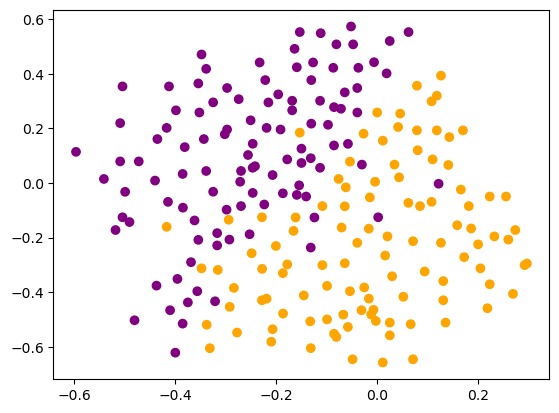

In [5]:
colors = ['orange' if label == 0 else 'purple' for label in data_train_y.ravel()]
plt.scatter(data_train_x[:, 0], data_train_x[:, 1], c=colors)

## Simple Model without regularization

In this model, we don't use any regularization methods. This neural network has 4 layers, with 4000 neurons in the first three layers. The output layer uses `sigmoid` activation function and the other layers use `ReLu`. The output layer has only one neuron due to the fact that this is a two-class problem.

The amount of neurons is a lot for a simple two-dimensional dataset, but with such a complicated model, we can see how overfitting occurs and then, how can we use regularization to avoid it.

In [6]:
model = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(4000, activation='relu'),
    keras.layers.Dense(4000, activation='relu'),
    keras.layers.Dense(4000, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')])

In this model, we use binary crossentropy loss function and "Adam" optimizer.

In [7]:
model.compile(optimizer="adam",
                loss='binary_crossentropy',
                metrics=['accuracy'])

In [8]:
history = model.fit(data_train_x, data_train_y,
                    epochs=500, batch_size=32,
                    validation_data=(data_eval_x, data_eval_y))

Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 757ms/step - accuracy: 0.7488 - loss: 0.4379 - val_accuracy: 0.8750 - val_loss: 0.4109
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 884ms/step - accuracy: 0.9052 - loss: 0.2754 - val_accuracy: 0.9050 - val_loss: 0.3339
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 581ms/step - accuracy: 0.8768 - loss: 0.3070 - val_accuracy: 0.9200 - val_loss: 0.2750
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 647ms/step - accuracy: 0.9147 - loss: 0.2569 - val_accuracy: 0.9200 - val_loss: 0.3415
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 599ms/step - accuracy: 0.9194 - loss: 0.2399 - val_accuracy: 0.9250 - val_loss: 0.3402
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 838ms/step - accuracy: 0.9100 - loss: 0.2368 - val_accuracy: 0.9300 - val_loss: 0.2802
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 762ms/step - accuracy: 0.9194 - loss: 0.2334 - val_accuracy: 0.9250 - val_loss: 0.3065
Epoch 8/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 702ms/step - accuracy: 0.9336 - loss: 0.2056 - val_accuracy: 0.9200 -

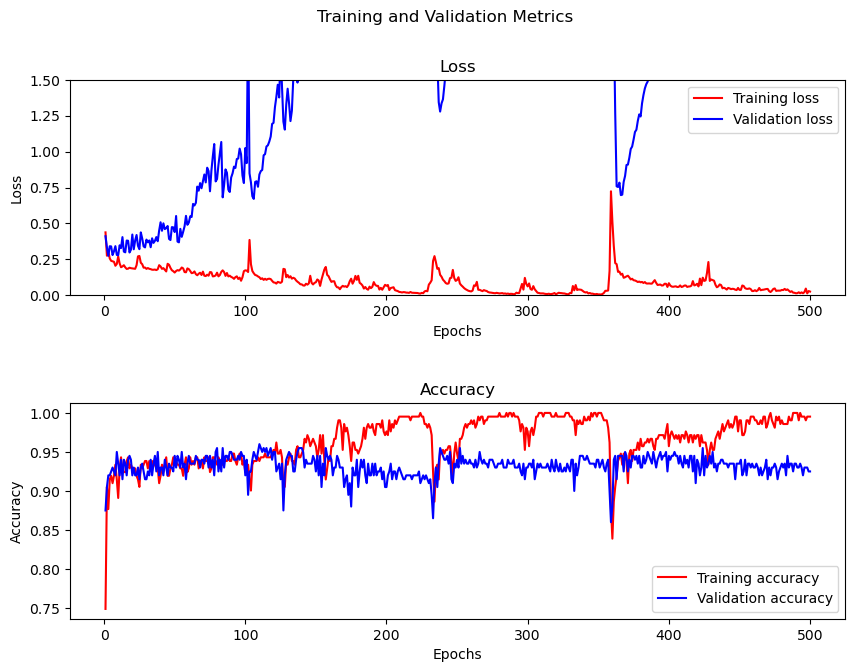

In [9]:
plot_loss_acc(history)

And we then use the function below to draw the classified boundaries in 2 dimensional space.

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step


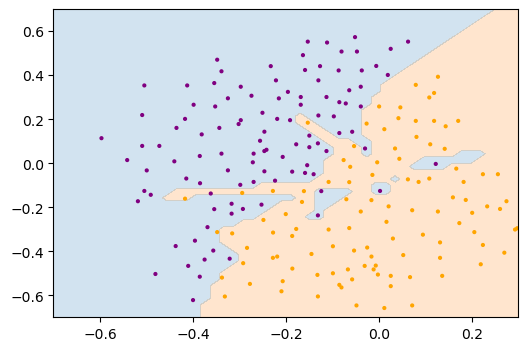

In [10]:
plot_decision_boundaries(model, -0.7, 0.3, -0.7, 0.7, 50)
colors = ['orange' if label == 0 else 'purple' for label in data_train_y.ravel()]
plt.scatter(data_train_x[:, 0], data_train_x[:, 1], c=colors, s=4)
plt.show()

## Dropout regularization

This time, we use the "Dropout" regularization method while training the model to avoid overfitting. The structure of network, and optimizing methods are the same as before.

In [11]:
model_dropout = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(4000, activation='relu'),
    keras.layers.Dropout(0.6),
    keras.layers.Dense(4000, activation='relu'),
    keras.layers.Dropout(0.6),
    keras.layers.Dense(4000, activation='relu'),
    keras.layers.Dropout(0.6),
    keras.layers.Dense(1, activation='sigmoid')])

In [12]:
model_dropout.compile(optimizer="adam",
                loss='binary_crossentropy',
                metrics=['accuracy'])

In [13]:
history_dropout = model_dropout.fit(data_train_x, data_train_y,
                            epochs=500, batch_size=32,
                            validation_data=(data_eval_x, data_eval_y))

Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 682ms/step - accuracy: 0.7773 - loss: 0.5744 - val_accuracy: 0.8900 - val_loss: 0.4630
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 457ms/step - accuracy: 0.8815 - loss: 0.3029 - val_accuracy: 0.9050 - val_loss: 0.3534
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 445ms/step - accuracy: 0.9052 - loss: 0.2512 - val_accuracy: 0.9200 - val_loss: 0.3184
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 443ms/step - accuracy: 0.9147 - loss: 0.2392 - val_accuracy: 0.9200 - val_loss: 0.2916
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 451ms/step - accuracy: 0.9336 - loss: 0.2277 - val_accuracy: 0.9200 - val_loss: 0.2781
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 466ms/step - accuracy: 0.9242 - loss: 0.2265 - val_accuracy: 0.9100 - val_loss: 0.3224
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 445ms/step - accuracy: 0.9147 - loss: 0.2426 - val_accuracy: 0.9400 - val_loss: 0.2884
Epoch 8/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 447ms/step - accuracy: 0.9194 - loss: 0.2401 - val_accuracy: 0.9150 - v

Now we draw the plots and regions for this model.

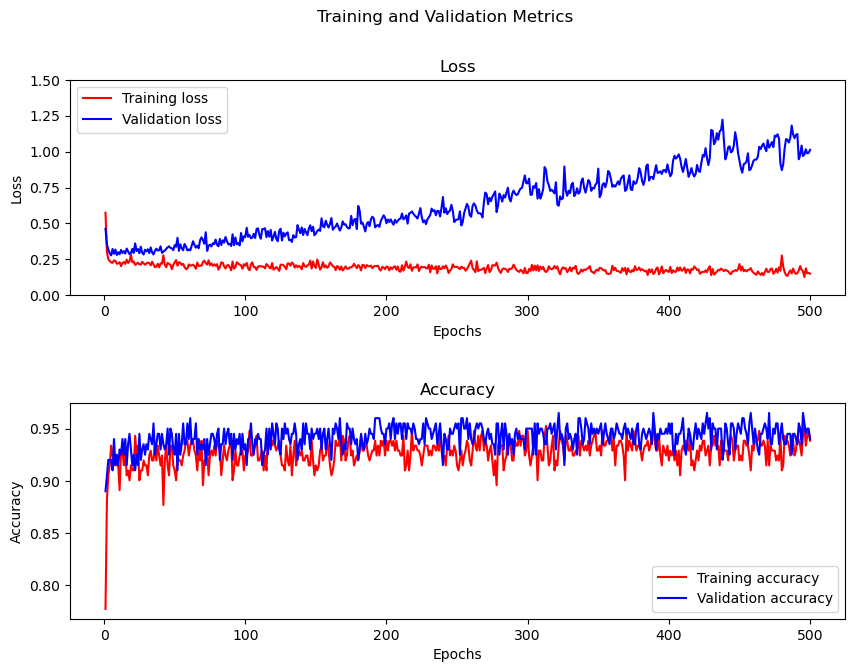

In [14]:
plot_loss_acc(history_dropout)

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step


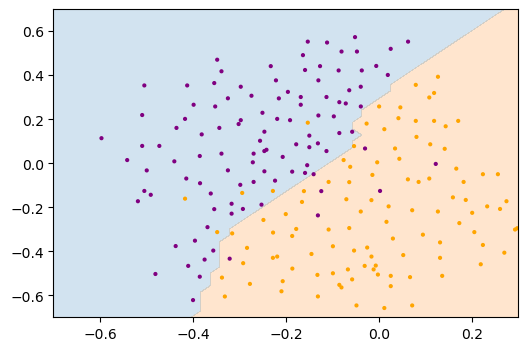

In [15]:
plot_decision_boundaries(model_dropout, -0.7, 0.3, -0.7, 0.7, 50)
colors = ['orange' if label == 0 else 'purple' for label in data_train_y.ravel()]
plt.scatter(data_train_x[:, 0], data_train_x[:, 1], c=colors, s=4)
plt.show()

## L1 regularization

In [16]:
model_l1 = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(4000, activation='relu', kernel_regularizer=regularizers.L1(3e-5)),
    keras.layers.Dense(4000, activation='relu', kernel_regularizer=regularizers.L1(3e-5)),
    keras.layers.Dense(4000, activation='relu', kernel_regularizer=regularizers.L1(3e-5)),
    keras.layers.Dense(1, activation='sigmoid', kernel_regularizer=regularizers.L1(3e-5))
    ])

In [17]:
model_l1.compile(optimizer="adam",
                loss='binary_crossentropy',
                metrics=['accuracy'])

In [18]:
history_l1 = model_l1.fit(data_train_x, data_train_y,
                        epochs=500, batch_size=32,
                        validation_data=(data_eval_x, data_eval_y))

Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 567ms/step - accuracy: 0.7346 - loss: 11.5050 - val_accuracy: 0.8850 - val_loss: 8.4627
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 506ms/step - accuracy: 0.8483 - loss: 6.9041 - val_accuracy: 0.9300 - val_loss: 4.8395
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 484ms/step - accuracy: 0.8720 - loss: 3.8913 - val_accuracy: 0.9250 - val_loss: 2.7018
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 484ms/step - accuracy: 0.9289 - loss: 2.2132 - val_accuracy: 0.9300 - val_loss: 1.8095
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 484ms/step - accuracy: 0.9336 - loss: 1.6869 - val_accuracy: 0.9150 - val_loss: 1.4471
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 492ms/step - accuracy: 0.9194 - loss: 1.2316 - val_accuracy: 0.9300 - val_loss: 1.0351
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 483ms/step - accuracy: 0.9194 - loss: 0.9469 - val_accuracy: 0.9200 - val_loss: 0.8240
Epoch 8/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 475ms/step - accuracy: 0.9242 - loss: 0.7662 - val_accuracy: 0.9100 - 

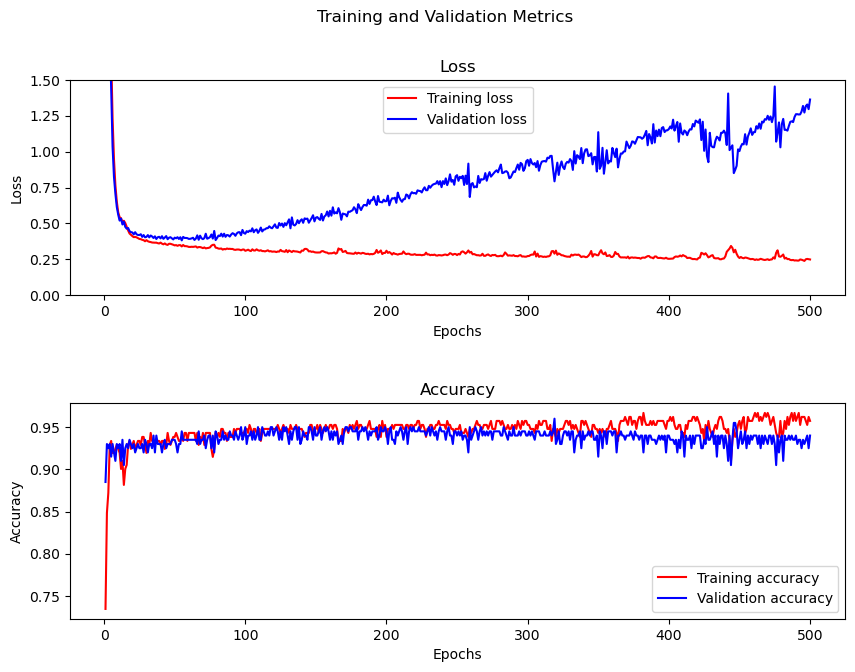

In [19]:
plot_loss_acc(history_l1)

79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step


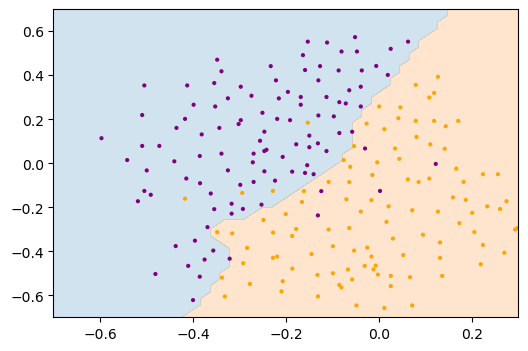

In [20]:
plot_decision_boundaries(model_l1, -0.7, 0.3, -0.7, 0.7, 50)
colors = ['orange' if label == 0 else 'purple' for label in data_train_y.ravel()]
plt.scatter(data_train_x[:, 0], data_train_x[:, 1], c=colors, s=4)
plt.show()

## L2 regularization

In [21]:
model_l2 = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(4000, activation='relu', kernel_regularizer=regularizers.L2(3e-4)),
    keras.layers.Dense(4000, activation='relu', kernel_regularizer=regularizers.L2(3e-4)),
    keras.layers.Dense(4000, activation='relu', kernel_regularizer=regularizers.L2(3e-4)),
    keras.layers.Dense(1, activation='sigmoid', kernel_regularizer=regularizers.L2(3e-4))
    ])

In [22]:
model_l2.compile(optimizer="adam",
                loss='binary_crossentropy',
                metrics=['accuracy'])

In [23]:
history_l2 = model_l2.fit(data_train_x, data_train_y,
                        epochs=500, batch_size=32,
                        validation_data=(data_eval_x, data_eval_y))

Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.8199 - loss: 2.4514 - val_accuracy: 0.8800 - val_loss: 1.7877
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9052 - loss: 1.4406 - val_accuracy: 0.9250 - val_loss: 1.0879
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8720 - loss: 0.9502 - val_accuracy: 0.9150 - val_loss: 0.7498
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9100 - loss: 0.6399 - val_accuracy: 0.9250 - val_loss: 0.5889
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9242 - loss: 0.4911 - val_accuracy: 0.9200 - val_loss: 0.5037
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9194 - loss: 0.4147 - val_accuracy: 0.9300 - val_loss: 0.4128
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9242 - loss: 0.3742 - val_accuracy: 0.9200 - val_loss: 0.4028
Epoch 8/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9242 - loss: 0.3452 - val_accuracy: 0.9350 - val_loss: 0.3580
Epoc

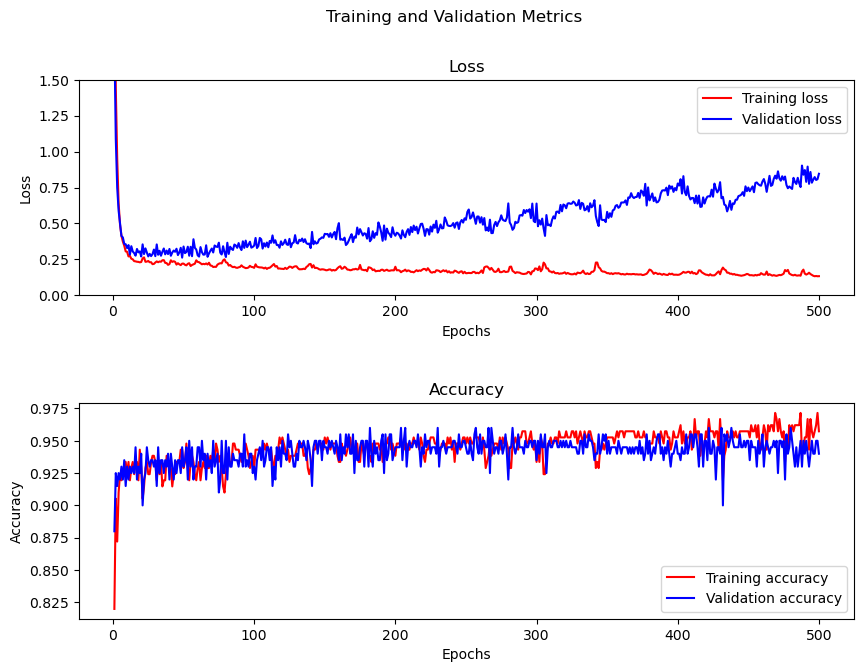

In [24]:
plot_loss_acc(history_l2)

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step


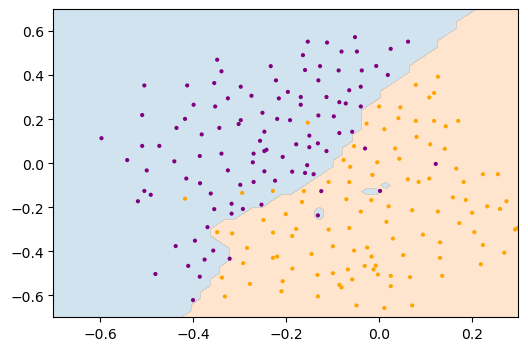

In [25]:
plot_decision_boundaries(model_l2, -0.7, 0.3, -0.7, 0.7, 50)
colors = ['orange' if label == 0 else 'purple' for label in data_train_y.ravel()]
plt.scatter(data_train_x[:, 0], data_train_x[:, 1], c=colors, s=4)
plt.show()

## L1L2 regularization

In [26]:
model_l1l2 = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(4000, activation='relu', kernel_regularizer=regularizers.L1L2(l1=3e-5, l2=3e-4)),
    keras.layers.Dense(4000, activation='relu', kernel_regularizer=regularizers.L1L2(l1=3e-5, l2=3e-4)),
    keras.layers.Dense(4000, activation='relu', kernel_regularizer=regularizers.L1L2(l1=3e-5, l2=3e-4)),
    keras.layers.Dense(1, activation='sigmoid', kernel_regularizer=regularizers.L1L2(l1=3e-5, l2=3e-4))
    ])

In [27]:
model_l1l2.compile(optimizer="adam",
                loss='binary_crossentropy',
                metrics=['accuracy'])

In [28]:
history_l1l2 = model_l1l2.fit(data_train_x, data_train_y,
                        epochs=500, batch_size=32,
                        validation_data=(data_eval_x, data_eval_y))

Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 662ms/step - accuracy: 0.7346 - loss: 13.3216 - val_accuracy: 0.8150 - val_loss: 9.5045
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 547ms/step - accuracy: 0.8957 - loss: 7.5018 - val_accuracy: 0.9200 - val_loss: 5.1138
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 540ms/step - accuracy: 0.9100 - loss: 3.9147 - val_accuracy: 0.9050 - val_loss: 2.5928
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 544ms/step - accuracy: 0.9005 - loss: 2.0702 - val_accuracy: 0.9300 - val_loss: 1.5998
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 542ms/step - accuracy: 0.9147 - loss: 1.5068 - val_accuracy: 0.8900 - val_loss: 1.4014
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 547ms/step - accuracy: 0.9100 - loss: 1.1343 - val_accuracy: 0.9250 - val_loss: 0.9131
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 542ms/step - accuracy: 0.8815 - loss: 0.8446 - val_accuracy: 0.8950 - val_loss: 0.8015
Epoch 8/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 547ms/step - accuracy: 0.8910 - loss: 0.7076 - val_accuracy: 0.9250 - 

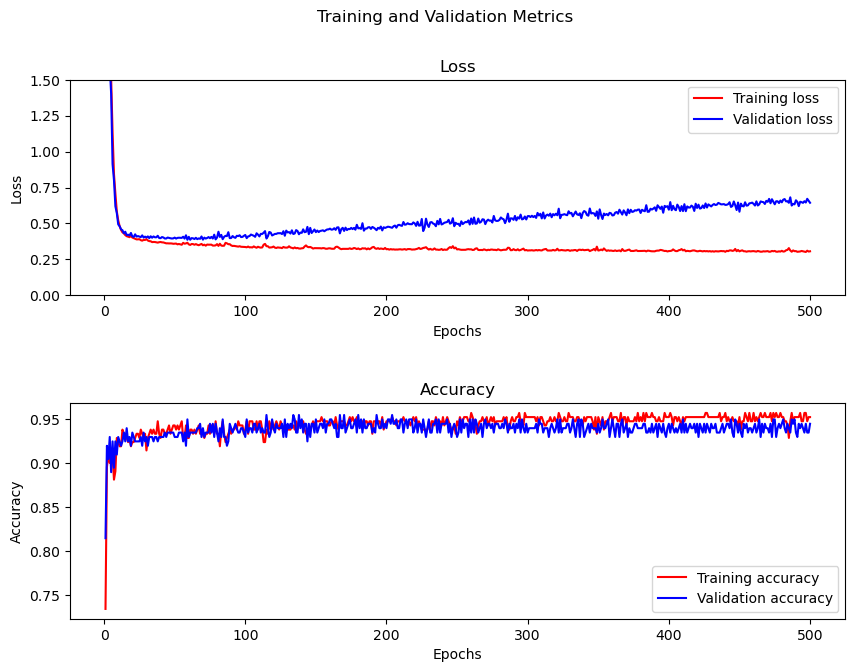

In [29]:
plot_loss_acc(history_l1l2)

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step


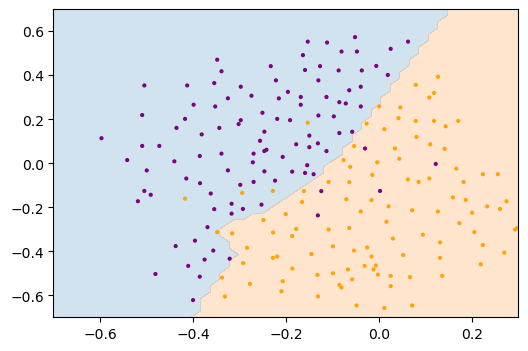

In [30]:
plot_decision_boundaries(model_l1l2, -0.7, 0.3, -0.7, 0.7, 50)
colors = ['orange' if label == 0 else 'purple' for label in data_train_y.ravel()]
plt.scatter(data_train_x[:, 0], data_train_x[:, 1], c=colors, s=4)
plt.show()

## Overall comparison and evaluation

In [31]:
models = [model, model_l1, model_l2, model_l1l2, model_dropout]
histories = [history, history_l1, history_l2, history_l1l2, history_dropout]
model_names = ['Simple Neural Network', 'Regularized with L1', 'Regularized with L2', 'Regularized with L1L2', 'Regulatized with Dropout']

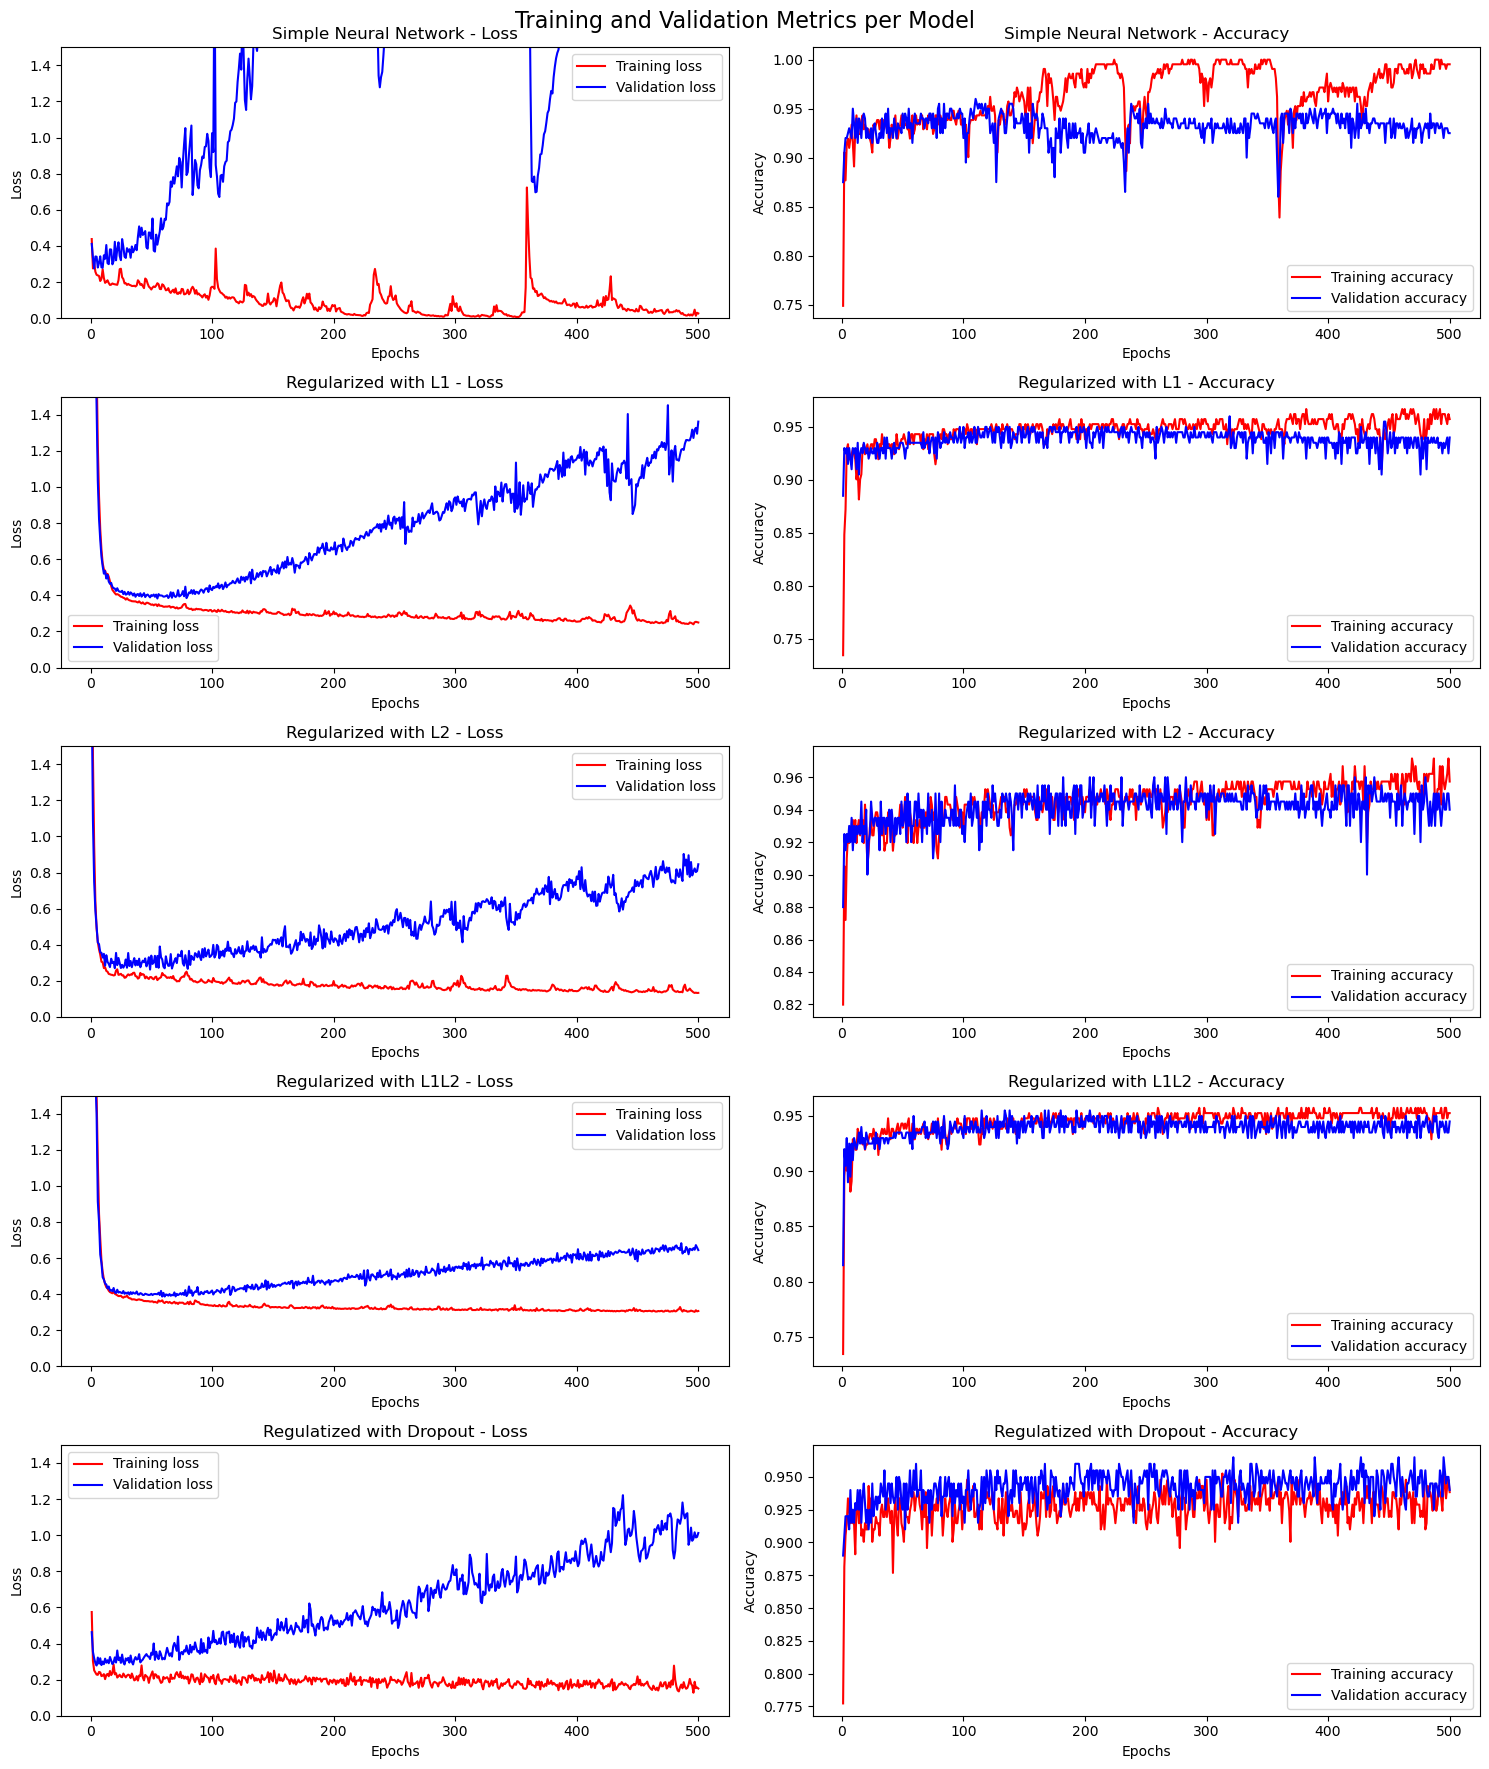

In [32]:
fig1, axes1 = plt.subplots(5, 2, figsize=(15, 18))
fig1.suptitle('Training and Validation Metrics per Model', fontsize=16)

for i, (hist, name) in enumerate(zip(histories, model_names)):
    ax_loss = axes1[i, 0]
    ax_acc = axes1[i, 1]
    plot_loss_acc_on_axes(hist, ax_loss, ax_acc, title=name)

plt.tight_layout()
plt.show()

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step


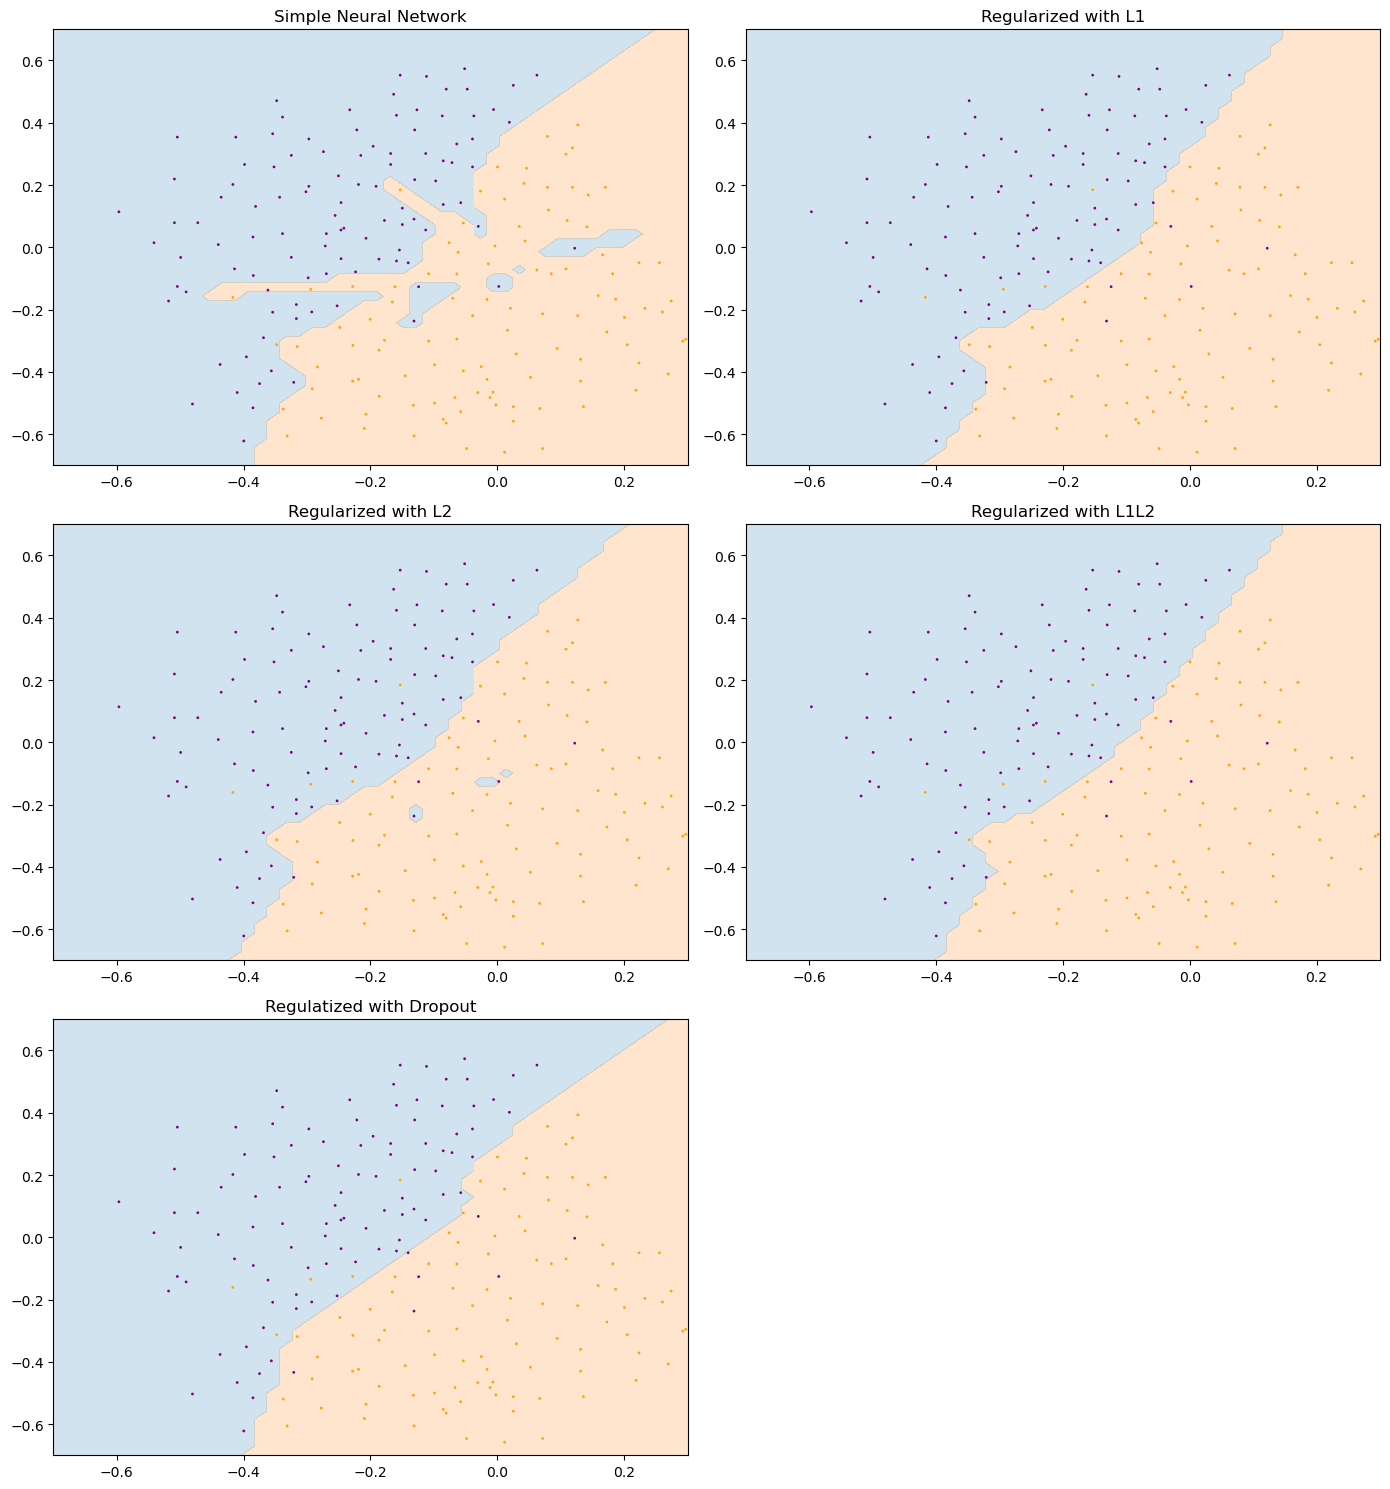

In [33]:
fig2, axes2 = plt.subplots(3, 2, figsize=(14, 15))
fig1.suptitle('Decision Boundaries', fontsize=16)


for i, (model, name) in enumerate(zip(models, model_names)):
    row = i // 2
    col = i % 2
    ax = axes2[row, col]
    plot_decision_boundaries_on_axes(
        model, ax,
        x_min=-0.7, x_max=0.3, y_min=-0.7, y_max=0.7, steps=50,
        data_x=data_train_x, data_y=data_train_y,
        title=name
    )

axes2[2, 1].axis('off')

plt.tight_layout()
plt.show()